In [1]:
import pandas as pd

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt


In [2]:
# examine SBS_D with respect to the new indel contexts

In [3]:
si = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_tumour_specific_Manuscript_v2.csv',index_col=0)

si_country =  pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_core_data_Manuscript_v2.csv',index_col=0)

si_marcos = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata_OG/CRC_metadata_2023SEP14.csv',index_col = 0)



mss_matrix =  pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/SBS_MSS_matrices/CRC_Manuscript_Subset_v2.SBS288.all',
             index_col=0)

matrix = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/trying_serena_new_ID_sigs/final_matrix.txt',
             index_col=0)

In [4]:
matrix.columns = matrix.columns.str.split('.').str[0].str.split('_').str[-1]

filtered_matrix = matrix.loc[:,mss_matrix.columns]

In [5]:
acts_serena = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/SPA_SERENA_ID/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',
                           index_col=0)

In [6]:
acts_MSA = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/pruned_attribution_CRC_Manuscript_denovo_SBS288_abs_mutations.csv',index_col=0)

id_acts_decomposed = pd.read_table('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/examine_SBS288D/SPA_SERENA_ID_DECOMPOSED/Assignment_Solution/Activities/Assignment_Solution_Activities.txt',
                                  index_col=0)

In [7]:
id_acts_decomposed = id_acts_decomposed / 100 # per 100 mutations

id_acts_decomposed['SBS_D'] = acts_MSA.loc[:,'SBS288D']>0

id_acts_decomposed['SBS_D_raw'] = acts_MSA.loc[:,'SBS288D']

In [8]:
si_marcos_full = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/Metadata_TMB_Signatures_SBS_ID_DBS_CN_SV_Drivers_2024AUG21.tsv',
             index_col=0)

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89902/3625486195.py:29: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  pvals = pd.Series(index = id_acts_decomposed.loc[:,'InD21':'InD9b'].columns)
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89902/3625486195.py:30: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  coef = pd.Series(index = id_acts_decomposed.loc[:,'InD21':'InD9b'].columns)


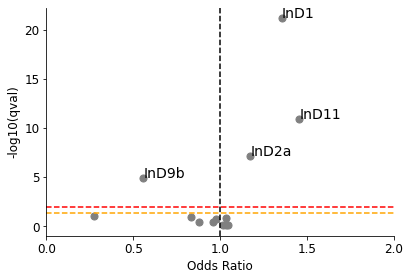

In [10]:
# okay, so we probably want to actually use a linear model for this
# maybe where the outcome variable is SBS_D pos/neg and then 
# the activity of each signature as a covariate (1 sig per model?)
# then can make a volcano plot
# and then just talk about which ones come up 




id_acts_decomposed['tumorsite_group'] = si_marcos_full.loc[:,'tumorsite_group']
id_acts_decomposed['sex'] = si_marcos_full.loc[:,'sex']
id_acts_decomposed['country'] = si_marcos_full.loc[:,'country']
id_acts_decomposed['age_diag'] = si_marcos_full.loc[:,'age_diag']
id_acts_decomposed['purity'] = si_marcos_full.loc[:,'purity']


id_acts_decomposed.loc[:,'SBS_D'] = id_acts_decomposed.loc[:,'SBS_D'].astype(int)

import statsmodels.api as sm

import statsmodels.formula.api as smf
from scipy import stats

import numpy as np

from statsmodels.stats.multitest import multipletests


pvals = pd.Series(index = id_acts_decomposed.loc[:,'InD21':'InD9b'].columns)
coef = pd.Series(index = id_acts_decomposed.loc[:,'InD21':'InD9b'].columns)

for sig in pvals.index:
    
    model = smf.glm(formula =  'SBS_D' + " ~ tumorsite_group  + sex + age_diag  + country + purity + " + sig, 
                data =id_acts_decomposed, family = sm.families.Binomial())
                #family = sm.families.Binomial())

    result = model.fit()
    # Display and interpret results
    pvals[sig] = (result.summary2().tables[1]).loc[:,'P>|z|'].loc[sig]
    coef[sig] = (result.summary2().tables[1]).loc[:,'Coef.'].loc[sig]
    
    

qvals = pd.Series(multipletests(pvals,method='fdr_bh')[1],index =pvals.index )
odds_ratios_red_meat = np.exp(coef)

import numpy as np 

fig,ax = plt.subplots(figsize=(5.8,4))
plt.scatter(odds_ratios_red_meat,
        -np.log10(qvals),color='grey',s=50)

plt.axhline(-np.log10(.05),color='orange',linestyle='--')
plt.axhline(-np.log10(.01),color='red',linestyle='--')

plt.axvline(1,color='black',linestyle='--')



plt.xlim(0,2)
plt.locator_params(axis='x', nbins=4)

for i, txt in enumerate(odds_ratios_red_meat.index):
    if qvals[i] > .05:
        continue
#     if txt == 'SBS5':
#         ax.annotate(txt,((odds_ratios_red_meat)[i], -np.log10(qvals)[i]-.1),fontsize=14)
#         continue

    ax.annotate(txt,((odds_ratios_red_meat)[i],
                     -np.log10(qvals)[i]),fontsize=14)

plt.xlabel('Odds Ratio')
plt.ylabel('-log10(qval)')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(12)
    
# plt.xticks(rotation=45)
# plt.title('Fat consumption',fontsize=14)
# plt.title(model.formula.replace('age_diag','age of diagnosis\n').replace(sig,'ID SIGNATURE'),
#          fontsize=14, y=1.1)

plt.tight_layout()
# 
# plt.savefig('reviewer_plots/serena_indels.png',dpi=300,
#            )


In [11]:
# InD9b is negatively associated? (no clear reason for that)

# postively associated
# InD1 - N-slip
# InD11 - " InD11 appeared related to InD1 and might be an oversplit signature frequently enriched 
                #in high InDel burden samples, such as those with MMRd and Pol-dys."
# InD2a - T-slip 

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89902/3675593476.py:47: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1].set_ylim(0,7000)


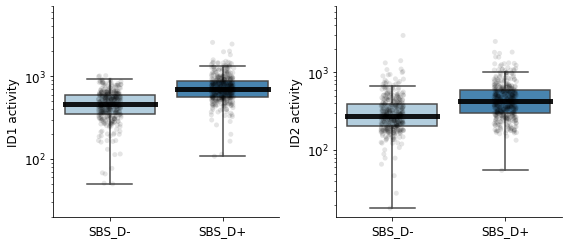

In [12]:
# Make Panel b 

indel_acts = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/checking_SBS288D_other_tissues/other_mutation_types_CRC/ID83/output_tables/pruned_attribution_CRC_Manuscript_COSMIC_ID83_abs_mutations.csv',
                      index_col=0)

indel_acts['SBS_D'] = id_acts_decomposed.loc[:,'SBS_D'].astype(str).str.replace('0','SBS_D-').str.replace('1','SBS_D+')

from statannotations.Annotator import Annotator

fig,ax = plt.subplots(1,2, figsize=(8,3.5))

sns.boxplot(data=indel_acts,
           x='SBS_D',y='ID1',ax=ax[0],palette='Blues',order=['SBS_D-','SBS_D+'],
           medianprops=dict(color="black", alpha=0.9,
                                          linewidth=5),fliersize=0)
sns.stripplot(data=indel_acts,
           x='SBS_D',y='ID1',ax=ax[0],order=['SBS_D-','SBS_D+'],
           color='black',alpha=.1)



sns.boxplot(data=indel_acts,
           x='SBS_D',y='ID2',ax=ax[1],palette='Blues',order=['SBS_D-','SBS_D+'],
           medianprops=dict(color="black", alpha=0.9,
                                          linewidth=5),fliersize=0)
sns.stripplot(data=indel_acts,
           x='SBS_D',y='ID2',ax=ax[1],order=['SBS_D-','SBS_D+'],
           color='black',alpha=.1)
ax[0].set_xlabel('')
ax[1].set_xlabel('')

ax[0].set_ylabel('ID1 activity')
ax[1].set_ylabel('ID2 activity')

for axx in ax:

    axx.spines['top'].set_visible(False)
    axx.spines['right'].set_visible(False)

    for item in ([axx.title, axx.xaxis.label, axx.yaxis.label] +
                 axx.get_xticklabels() + axx.get_yticklabels()):
        item.set_fontsize(12)
ax[0].set_yscale('log')  
ax[1].set_yscale('log')

ax[0].set_ylim(20,7000)
ax[1].set_ylim(0,7000)

        
# pairs=[ ('SBS_D-','SBS_D+')]

# annotator = Annotator(ax[0], pairs, data=indel_acts,
#           x='SBS_D',y='ID1',palette='Blues',order=['SBS_D-','SBS_D+'])

# annotator.configure(test='Mann-Whitney', text_format='star', loc='outside',
#                    comparisons_correction="BH")
# annotator.apply_and_annotate()


# annotator = Annotator(ax[1], pairs, data=indel_acts,
#           x='SBS_D',y='ID2',palette='Blues',order=['SBS_D-','SBS_D+'])

# annotator.configure(test='Mann-Whitney', text_format='star', loc='outside',
#                    comparisons_correction="BH")
# annotator.apply_and_annotate()


plt.tight_layout()
# plt.savefig('reviewer_plots/ID1_ID2.png',dpi=300)


In [13]:
# signficance for panel b 

In [14]:
indel_acts['tumorsite_group'] = si_marcos_full.loc[:,'tumorsite_group']
indel_acts['age_diag'] = si_marcos_full.loc[:,'age_diag']
indel_acts['sex'] = si_marcos_full.loc[:,'sex']
indel_acts['country'] = si_marcos_full.loc[:,'country']
indel_acts['purity'] = si_marcos_full.loc[:,'purity']

# want the p-values to come from linear models 

model = smf.glm(formula =  'SBS_D' + " ~ tumorsite_group  + sex + age_diag  + country + purity + ID1", 
            data =indel_acts, family = sm.families.Binomial())
            #family = sm.families.Binomial())

result = model.fit()

result.summary2().tables[1].loc['ID1','P>|z|']


6.860612487877842e-37

In [15]:
model = smf.glm(formula =  'SBS_D' + " ~ tumorsite_group  + sex + age_diag  + country + purity + ID2", 
            data =indel_acts, family = sm.families.Binomial())
            #family = sm.families.Binomial())

result = model.fit()

result.summary2().tables[1].loc['ID2','P>|z|']

1.5565809839914256e-13